In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.makedirs("charts", exist_ok=True)

# 1. Load the data

In [3]:
d = pd.read_csv("data/credit_record.csv")
f = pd.read_csv("data/application_record.csv")

# 2. Review the data structure

In [4]:
f.columns 

Index(['ID', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN',
       'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH',
       'DAYS_EMPLOYED', 'FLAG_MOBIL', 'FLAG_WORK_PHONE', 'FLAG_PHONE',
       'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS'],
      dtype='object')

In [5]:
d.columns

Index(['ID', 'MONTHS_BALANCE', 'STATUS'], dtype='object')

In [6]:
f.head(20)

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
5,5008810,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
6,5008811,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
7,5008812,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
8,5008813,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0
9,5008814,F,N,Y,0,283500.0,Pensioner,Higher education,Separated,House / apartment,-22464,365243,1,0,0,0,NaN,1.0


In [7]:
d.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [8]:
d["target"] = d["STATUS"].isin(["2", "3", "4", "5"]).astype(int)
target = d.groupby("ID")["target"].max().reset_index()
target.columns = ["ID", "target"]

print(target["target"].value_counts())
print(target["target"].value_counts(normalize=True))

target
0    45318
1      667
Name: count, dtype: int64
target
0    0.985495
1    0.014505
Name: proportion, dtype: float64


In [9]:
print(f["FLAG_OWN_CAR"].value_counts())
print(f["FLAG_OWN_CAR"].value_counts(normalize = True))

FLAG_OWN_CAR
N    275459
Y    163098
Name: count, dtype: int64
FLAG_OWN_CAR
N    0.628103
Y    0.371897
Name: proportion, dtype: float64


In [10]:
print(f["FLAG_OWN_REALTY"].value_counts())
print(f["FLAG_OWN_REALTY"].value_counts(normalize = True))

FLAG_OWN_REALTY
Y    304074
N    134483
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    0.693351
N    0.306649
Name: proportion, dtype: float64


In [11]:
print(f["CODE_GENDER"].value_counts())
print(f["CODE_GENDER"].value_counts(normalize = True))

CODE_GENDER
F    294440
M    144117
Name: count, dtype: int64
CODE_GENDER
F    0.671384
M    0.328616
Name: proportion, dtype: float64


In [12]:
print(f["CNT_CHILDREN"].value_counts())
print(f["CNT_CHILDREN"].value_counts(normalize = True))

CNT_CHILDREN
0     304071
1      88527
2      39884
3       5430
4        486
5        133
7          9
9          5
12         4
6          4
14         3
19         1
Name: count, dtype: int64
CNT_CHILDREN
0     0.693344
1     0.201860
2     0.090944
3     0.012382
4     0.001108
5     0.000303
7     0.000021
9     0.000011
12    0.000009
6     0.000009
14    0.000007
19    0.000002
Name: proportion, dtype: float64


In [13]:
print(f["NAME_FAMILY_STATUS"].value_counts())
print(f["NAME_FAMILY_STATUS"].value_counts(normalize = True))

NAME_FAMILY_STATUS
Married                 299828
Single / not married     55271
Civil marriage           36532
Separated                27251
Widow                    19675
Name: count, dtype: int64
NAME_FAMILY_STATUS
Married                 0.683669
Single / not married    0.126029
Civil marriage          0.083300
Separated               0.062138
Widow                   0.044863
Name: proportion, dtype: float64


# 3. Explanatory Data Analysis (EDA)

# 3.1 Statistical Analysis

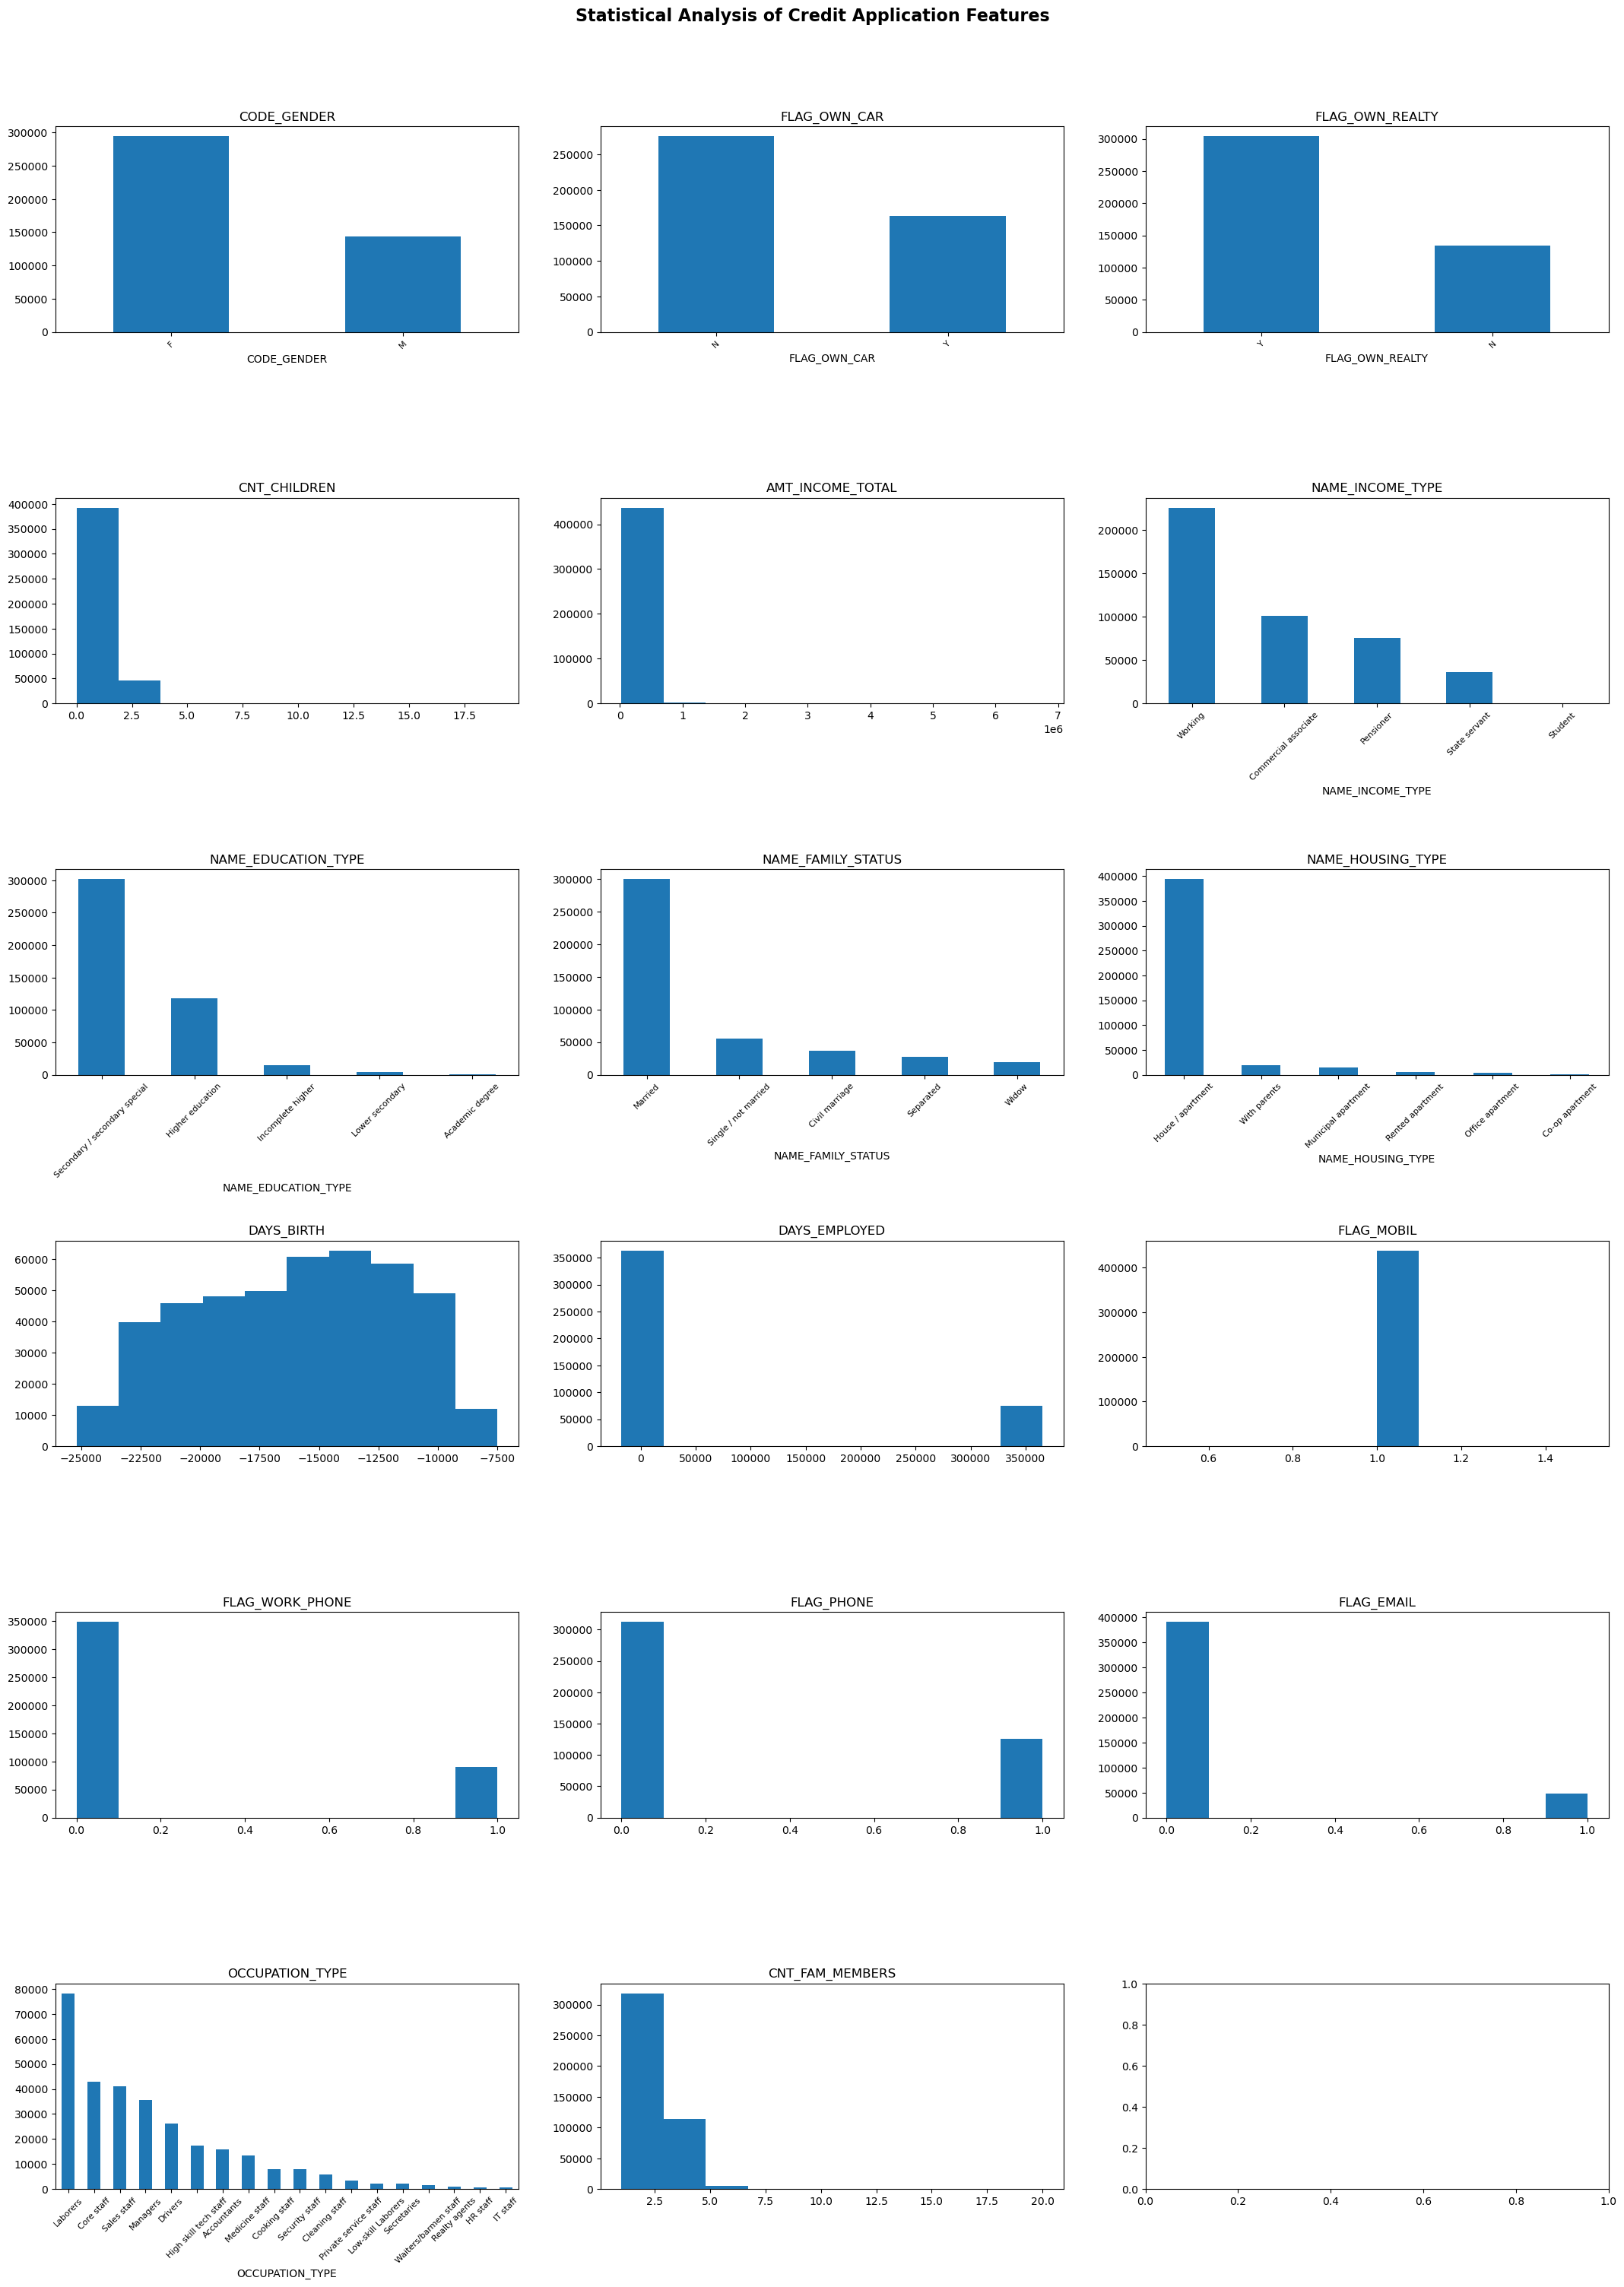

In [14]:
fig, ax = plt.subplots(6, 3, figsize=(22, 30))
ax = ax.flatten()

plt.suptitle("Statistical Analysis of Credit Application Features", 
             fontsize=16, fontweight="bold", y=1.01)

col = f.columns.drop("ID").tolist()

for i,cols in enumerate(col):
    if f[cols].dtype == "object":
        f[cols].value_counts().plot(kind='bar',ax=ax[i])
        ax[i].tick_params(axis='x',rotation=45,labelsize=8)
    else:
        ax[i].hist(f[cols])
    ax[i].set_title(cols)
plt.savefig("charts/statistical_analysis.png", dpi=150, bbox_inches="tight")
plt.tight_layout(pad=3.0)
plt.show()

## 3.2 Missing Values Analysis

In [15]:
f.isnull().sum()
f.isnull().sum() / len(f) * 100  # percentage

ID                      0.000000
CODE_GENDER             0.000000
FLAG_OWN_CAR            0.000000
FLAG_OWN_REALTY         0.000000
CNT_CHILDREN            0.000000
AMT_INCOME_TOTAL        0.000000
NAME_INCOME_TYPE        0.000000
NAME_EDUCATION_TYPE     0.000000
NAME_FAMILY_STATUS      0.000000
NAME_HOUSING_TYPE       0.000000
DAYS_BIRTH              0.000000
DAYS_EMPLOYED           0.000000
FLAG_MOBIL              0.000000
FLAG_WORK_PHONE         0.000000
FLAG_PHONE              0.000000
FLAG_EMAIL              0.000000
OCCUPATION_TYPE        30.601039
CNT_FAM_MEMBERS         0.000000
dtype: float64

## 3.3 Outlier Analysis

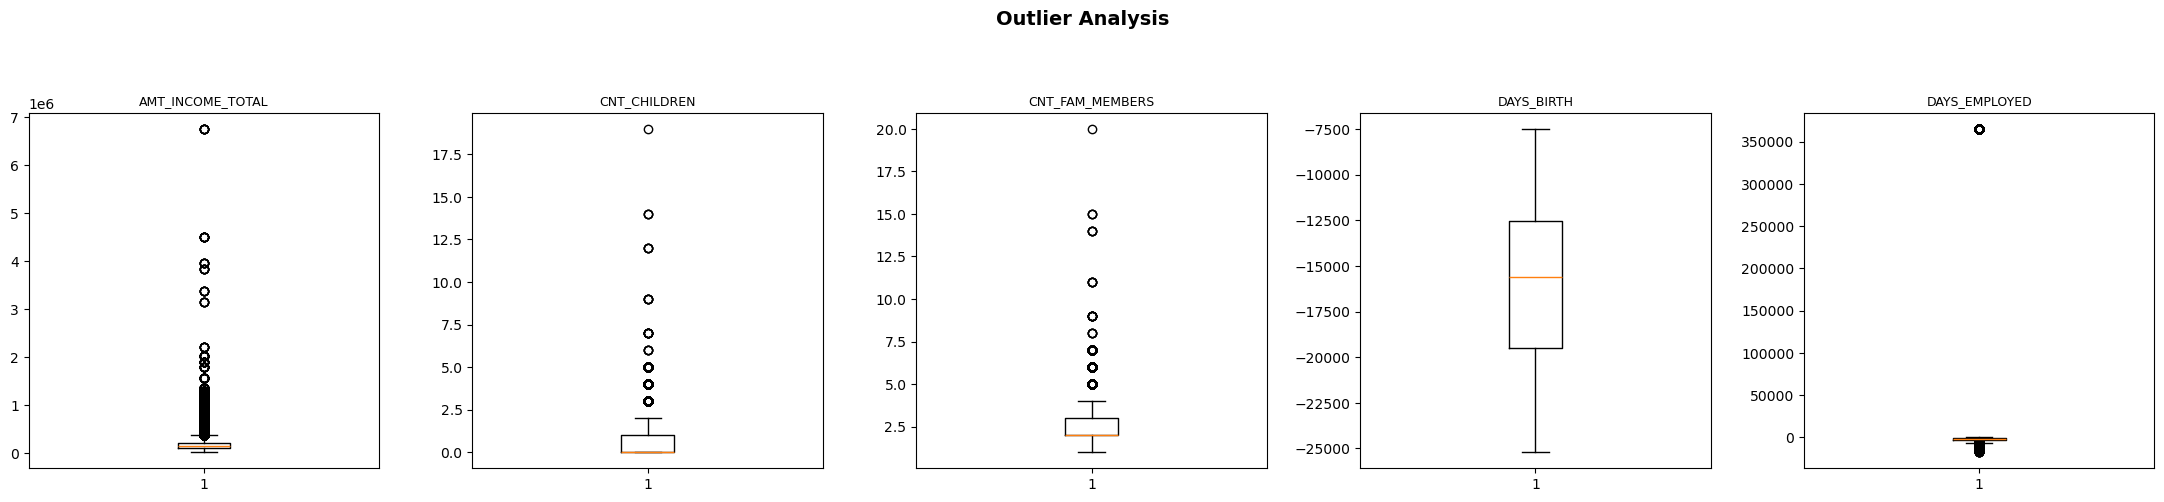

In [16]:
num_cols = ["AMT_INCOME_TOTAL", "CNT_CHILDREN", "CNT_FAM_MEMBERS", 
            "DAYS_BIRTH", "DAYS_EMPLOYED"]

fig, ax = plt.subplots(1, 5, figsize=(22, 5))
ax = ax.flatten()

for i, cols in enumerate(num_cols):
    ax[i].boxplot(f[cols].dropna())
    ax[i].set_title(cols, fontsize=9)

plt.suptitle("Outlier Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(pad=2.0)
plt.savefig("charts/outlier_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Correlation heatmap

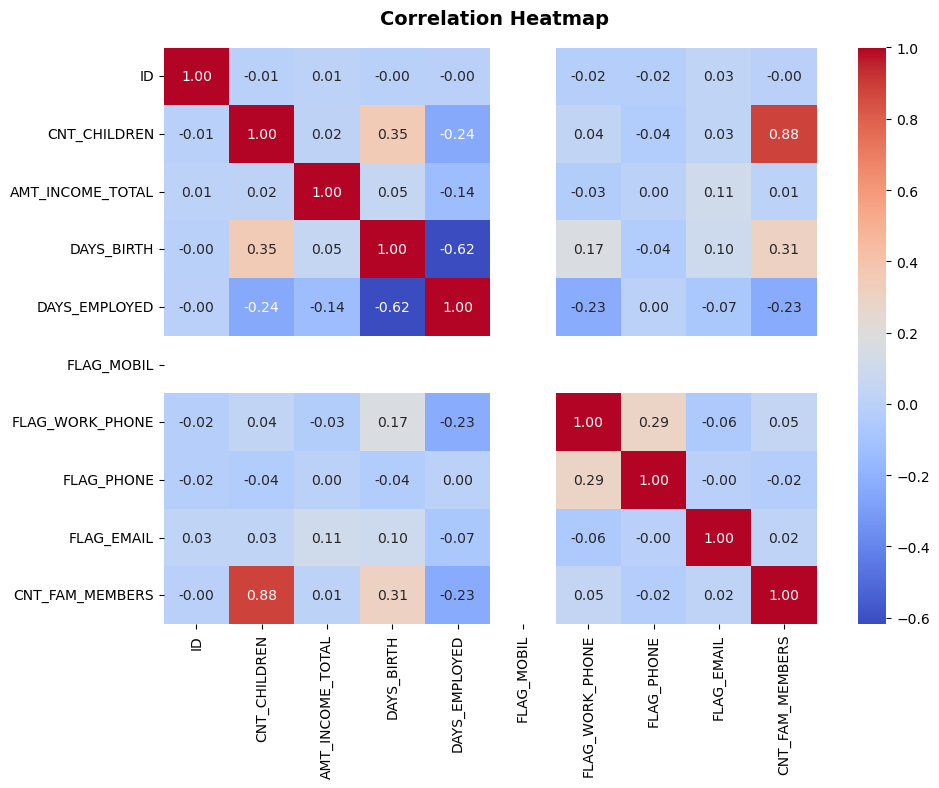

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = f.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
plt.suptitle("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("charts/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# 4. Preprocessing

In [28]:
df = f.merge(target, on="ID", how="inner")

In [29]:
df["AGE_YEARS"] = (-df["DAYS_BIRTH"] / 365).astype(int)
df.drop(columns=["DAYS_BIRTH"], inplace=True)

In [30]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
df["YEARS_EMPLOYED"] = (-df["DAYS_EMPLOYED"] / 365)
df.drop(columns=["DAYS_EMPLOYED"], inplace=True)

In [31]:
df["OCCUPATION_TYPE"] = df["OCCUPATION_TYPE"].fillna("Unknown")

In [32]:
df.dtypes

ID                       int64
CODE_GENDER             object
FLAG_OWN_CAR            object
FLAG_OWN_REALTY         object
CNT_CHILDREN             int64
AMT_INCOME_TOTAL       float64
NAME_INCOME_TYPE        object
NAME_EDUCATION_TYPE     object
NAME_FAMILY_STATUS      object
NAME_HOUSING_TYPE       object
FLAG_MOBIL               int64
FLAG_WORK_PHONE          int64
FLAG_PHONE               int64
FLAG_EMAIL               int64
OCCUPATION_TYPE         object
CNT_FAM_MEMBERS        float64
target                   int64
AGE_YEARS                int64
YEARS_EMPLOYED         float64
dtype: object

In [33]:
columns_obj = df.select_dtypes(include="object").columns.tolist()

In [34]:
columns_obj

['CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE']

In [35]:
df["AMT_INCOME_TOTAL"] = np.log1p(df["AMT_INCOME_TOTAL"])

In [36]:
from sklearn.model_selection import train_test_split

In [38]:
x = df.drop(columns=["target", "ID", "FLAG_MOBIL", "CNT_FAM_MEMBERS"])
y = df["target"]

In [49]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [58]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline as SkPipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [59]:
models = {
    "LightGBM": lgb.LGBMClassifier(scale_pos_weight=68, random_state=42),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "LogisticRegression": LogisticRegression(class_weight="balanced", random_state=42)}

In [60]:
binary_cols = ["CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY"]
cat_cols = ["NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE", 
            "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE"]
num_cols = ["CNT_CHILDREN", "AMT_INCOME_TOTAL", "FLAG_WORK_PHONE", 
            "FLAG_PHONE", "FLAG_EMAIL", "AGE_YEARS", "YEARS_EMPLOYED"]

preprocessor = ColumnTransformer(transformers=[
    ("num", SkPipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols + binary_cols)])
results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(x_train, y_train)
    y_pred = pipeline.predict(x_test)
    y_pred_proba = pipeline.predict_proba(x_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_pred_proba)
    results[name] = auc
    
    print(f"\n{name}: AUC-ROC = {auc:.4f}")
    print(classification_report(y_test, y_pred))

print("\nBest model:", max(results, key=results.get))

[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001153 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 29165, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016904 -> initscore=-4.063167
[LightGBM] [Info] Start training from score -4.063167


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM: AUC-ROC = 0.6966
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      7169
           1       0.06      0.46      0.11       123

    accuracy                           0.88      7292
   macro avg       0.53      0.67      0.52      7292
weighted avg       0.97      0.88      0.92      7292


RandomForest: AUC-ROC = 0.7854
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      7169
           1       0.17      0.36      0.23       123

    accuracy                           0.96      7292
   macro avg       0.58      0.66      0.60      7292
weighted avg       0.97      0.96      0.97      7292


LogisticRegression: AUC-ROC = 0.5583
              precision    recall  f1-score   support

           0       0.99      0.58      0.73      7169
           1       0.02      0.50      0.04       123

    accuracy                           0.58      7292
   macro avg       0.50      0

In [63]:
from sklearn.model_selection import RandomizedSearchCV

lgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", lgb.LGBMClassifier(random_state=42))
])

param_grid = {
    "model__num_leaves": [31, 50, 70, 100],
    "model__max_depth": [5, 7, 10, -1],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__min_child_samples": [20, 50, 100],
    "model__n_estimators": [100, 200, 300],
    "model__scale_pos_weight": [30, 50, 68, 90]
}

search = RandomizedSearchCV(
    lgb_pipeline,
    param_distributions=param_grid,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(x_train, y_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV AUC: {search.best_score_:.4f}")

# Evaluate on test set
y_pred_proba = search.predict_proba(x_test)[:, 1]
y_pred = search.predict(x_test)
auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nTest AUC-ROC: {auc:.4f}")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

[LightGBM] [Info] Number of positive: 395, number of negative: 22937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003921 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 594
[LightGBM] [Info] Number of data points in the train set: 23332, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016930 -> initscore=-4.061621
[LightGBM] [Info] Start training from score -4.061621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 395, number of negative: 22937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003756 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 595
[LightGBM] [Info] Number of data points in the train set: 23332, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016930 -> initscore=-4.061621
[LightGBM] [Info] Start training from score -4.061621
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

[LightGBM] [Info] Number of positive: 493, number of negative: 28672
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001072 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 617
[LightGBM] [Info] Number of data points in the train set: 29165, number of used features: 52
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.016904 -> initscore=-4.063167
[LightGBM] [Info] Start training from score -4.063167
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best params: {'model__scale_pos_weight': 50, 'model__num_leaves': 70, 'model__n_estimators': 300, 'model__min_child_samples': 20, 'model__max_depth': 10, 'model__learning_rate': 0.1}
Best CV AUC: 0.7524

Test AUC-ROC: 0.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [65]:
import joblib
joblib.dump(search, "best_model.pkl")

['best_model.pkl']

In [ ]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=42))
])
rf_pipeline.fit(x_train, y_train)
joblib.dump(rf_pipeline, "best_model.pkl")

NameError: name 'X_train' is not defined